# Train a decoder model for ESM-2.


## Abstract

This notebook attempts to train two decoder models for ESM-2, the first decoder uses the full-length ESM-2 embeddings and the second decoder uses the mean-pooled ESM-2 embeddings. Learning a mapping between the full-length ESM-2 embeddings and residues is straightforward as we retain residue-level data.  We achieved a test accuracy of 0.9998 and an AUROC-macro of 1.0 indicating the model learned a nearly perfect mapping between the full-length embedding and amino acids across all natural residues. The mean-pooled decoder exhibits model collapse with a test accuracy of 0.103 and an AUROC-macro of 0.371 indicating the model is unable to learn a meaningful mapping and performs worse than random when weighting all natural residues equally.


## Introduction

ESM-2 is a bi-directional encoder-only masked language model trained on a large corpus of amino acid sequences [Lin et al. 2022](https://www.science.org/doi/abs/10.1126/science.ade2574); for downstream tasks, ESM-2 can compute embeddings for amino acid sequences which are representations of the discrete residues in continuous space. It is easier to traverse a continuous embedding space than a discrete residue space because we can compute gradients in continuous spaces but we cannot in discrete spaces. Traversing a continuous space is critical for gradient-based optimization strategies where we can identify promising candidates in embedding space. If we find a sequence embedding with promising features, ESM-2 cannot directly map the embedding to an amino acid sequence; however, we can train a decoder model to do so.


## Project Goals


Train a (generative) decoder model to predict amino acid sequences from ESM-2 embeddings.

We can build a decoder model for both embedding sizes:
1. **Embedding [$d_{model}$  x $ d_{embedding}$ x $L_{sequence}$]**
- The length of the amino acid sequence is defined by the dimension $L_{sequence}$ in the embedding shape. For each position in $L_{sequence}$, there is [$d_{model}$  x $ d_{embedding}$] predictors.
- The model objective becomes a lookup task.

2. **Mean-pooled embeddings: [$d_{model}$ x $d_{embedding}$]**
- The length of the amino acid sequence is not defined because we averaged across the length of the sequence. The [$d_{model}$  x $ d_{embedding}$] pooled predictors capture all the information for the entire amino acid sequence.
- The model must reconstruct variable-length sequence from a fixed-length embedding vector is information-theoretically underspecified. There exist different amino acid sequences that can produce the same mean-pooled embedding so the decoder cannot uniquely recover orginial sequence.

# 00: Install and import relevant packages.
- fair-esm: module to load ESM model parameters and process outputs.
- [homolog-search-tools](https://github.com/chrisnguyen11/homolog-search-tools): package with functions to parse FASTA files and interact with UniProt API in python.


In [2]:
!pip install -q fair-esm
!pip install -q git+https://github.com/chrisnguyen11/homolog-search-tools.git
!pip install -q torchmetrics

  Preparing metadata (setup.py) ... done


In [3]:
# utility
from typing import List
import re
from tqdm.notebook import tqdm
import json

# data science
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ml
import torch
import torch.nn as nn
from torch.nn.functional import softmax
from torchmetrics.functional.classification import (multiclass_accuracy,
    multiclass_f1_score, multiclass_recall, multiclass_precision,
    multiclass_specificity, multiclass_auroc, multiclass_calibration_error
)

# Protein Modeling
import esm
from esm import FastaBatchedDataset
from homolog_search_tools.utils import write_fasta, read_fasta
from homolog_search_tools.search import UniProtRequest, uniprotrecords_to_dataframe

In [4]:
np.random.seed(42)
torch.manual_seed(42)

# 01: Preprocess training data.

- ESM-2 was trained on [UniRef50](https://www.uniprot.org/help/uniref), a subset of UniProt which have been clustered so that the remaining sequences are diverse without much redundancy.

- Parse UniRef50 accessions from the [ESM-2 repo](https://github.com/facebookresearch/esm?tab=readme-ov-file#pre-training-dataset-split--) and fetch a handful of sequences to construct our dataset.

- Ensure accessions follows the [UniProt accession pattern](https://www.uniprot.org/help/accession_numbers), the file also contains UniParc accessions which are not parsed in this analysis.

In [6]:
# parse list of vaild accessions
pattern = "[OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z][A-Z0-9]{2}[0-9]){1,2}"

accessions = []
with open("uniref201803_ur50_valid_headers.txt","r") as f:
  for line in f:
    try:
      accessions.append(re.search(pattern,line)[0])
    except:
      pass

len(accessions)

2593772

In [7]:
# fetch UniProt data from accessions
uniprot_api = UniProtRequest("cnguyen11@luc.edu")
records = uniprot_api.fetch_records(accessions[:20_000])

records_df = uniprotrecords_to_dataframe(records)
records_df["sequenceLength"].describe()

,sequenceLength
count,12095.000000
mean,331.812402
std,409.202615
min,11.000000
25%,119.000000
50%,228.000000
75%,408.000000
max,16023.000000


In [8]:
n = 12_000
write_fasta(records_df.iloc[:n], f"uniref201803_ur50_{n}.fasta",
            header_col="primaryAccession", sequence_col="sequence")

# 02: Compute ESM-2 embeddings.

- Functions to interact with the ESM-2 models are based on the a script from the [ESM GitHub repo](https://github.com/facebookresearch/esm/blob/main/scripts/extract.py)


In [9]:
model, alphabet =  esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


In [10]:
def extract(
    model, alphabet, sequences, repr_layers=[], agg="mean",
    truncation_seq_length=1022,
    toks_per_batch=4096, ALPHABET = "LAGVSERTIDPKQNFWYMHC",
    device="cuda"
    ):
  """
  Extracts and processes sequence representations using ESM-2. Code modified
  from the [extract.py](https://github.com/facebookresearch/esm/blob/main/scripts/extract.py)
  in the ESM repo.

  Parameters
  ----------
  model: str
    ESM model object.
  alphabet: str
    ESM alphabet object.
  sequences: str
    Path to fasta file.
  repr_layers: list[int]
    List of layers to extract representations from.
  """
  # Load model parameters and sequence data
  model.to(device)
  model.eval()
  dataset = esm.FastaBatchedDataset.from_file(sequences)
  batches = dataset.get_batch_indices(toks_per_batch, extra_toks_per_seq=1)
  data_loader = torch.utils.data.DataLoader(
    dataset, collate_fn=alphabet.get_batch_converter(truncation_seq_length),
    batch_sampler=batches
  )
  tok_to_idx = alphabet.tok_to_idx

  # Inference
  with torch.no_grad():
    output = []
    for batch_idx, (labels, strs, toks) in tqdm(enumerate(data_loader)):
      toks = toks.to(device=device) # Move toks to the specified device
      batch_output = model(toks, repr_layers=repr_layers)
      batch_logits = batch_output["logits"].to(device=device)
      batch_representations = {
          layer: rep.to(device="cpu") for layer, rep in batch_output["representations"].items()}

      for i, label in enumerate(labels):
        # Compute LL
        seq_length = truncation_seq_length if len(strs[i]) > truncation_seq_length else len(strs[i])
        batch_probs = torch.nn.functional.softmax(batch_logits[i, 1:seq_length+1], dim=1)
        batch_log_probs = torch.log(batch_probs)
        residue_log_probs = [batch_log_probs[j, tok_to_idx[aa]].item() for j, aa in enumerate(strs[i]) if j < seq_length]

        log_prob = (1/seq_length) * np.sum(residue_log_probs)

        perplexity = np.exp(-log_prob)

        # Save sequence data
        _output = {
            "Sequence":strs[i], "perplexity":perplexity, "log_likelihood":log_prob,
            "batch_probs": batch_probs
            }
        if len(repr_layers) > 0:
          _output["embedding"] = batch_representations[repr_layers[0]][i, 1:seq_length+1].numpy()
          _output["mean_embedding"] = batch_representations[repr_layers[0]][i, 1:seq_length+1].mean(0).numpy()
        output.append(_output)
  return output

out = extract(model, alphabet, f"uniref201803_ur50_{n}.fasta", [6], device="cuda")

0it [00:00, ?it/s]

# 03: Train embedding decoder.

- Define functions to help the training process.

- Define the decoder model.

In [11]:
# train-test functions

def mini_batch_indices(n_samples, batch_size, n_epoch) -> List[np.array]:
  "Generate N_samples * N_epoch groupedby batch_size."
  n_splits = n_samples / batch_size
  indices = list(range(n_samples))

  splits = []
  for epoch in range(n_epoch):
    splits.extend([
        (epoch, split) for split in np.array_split(indices, n_splits)]
    )
    indices = np.random.permutation(indices)
  return splits

def train_val_test_split_indices(n_samples,
                             train_proportion, test_proportion, val_proportion=0
                             ):
  "Split N_samples into train, validation, and test splits."

  if train_proportion + test_proportion + val_proportion != 1:
    raise ValueError("Train, test, and validation proportions must sum to 1.")

  train_indices = np.random.choice(n_samples, int(n_samples * train_proportion), replace=False)
  remaining_indices = np.array(list(set(range(n_samples)) - set(train_indices)))

  val_indices = np.random.choice(remaining_indices, int(n_samples * val_proportion), replace=False)
  test_indices = np.array(list(set(remaining_indices) - set(val_indices)))
  return train_indices, test_indices, val_indices

np.random.seed(42)
mini_batch_indices(10, 5, 4)[2]
train_val_test_split_indices(10, 0.8, 0.1, 0.1)

(array([1, 5, 4, 8, 0, 7, 6, 3]), array([9]), array([2]))

In [12]:
# define decoder model

class ESMDecoder(nn.Module):
  def __init__(self, alphabet_size: int = 33, hidden_dim: int = 320,
               layers: int = 3, dropout: float = 0.1, sigmoid: bool = False,
               lr: float = 1e-4 ) -> None:
    super().__init__()
    self.lr = lr

    layers = [nn.Linear(hidden_dim, alphabet_size)]

    if sigmoid:
      layers.append(nn.Sigmoid())

    self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)

In [13]:
idx_to_tok = {i:a for a, i in alphabet.to_dict().items()}

esm_decoder = ESMDecoder(dropout=0.3)
optimizer = torch.optim.Adam(esm_decoder.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
esm_decoder.to("cuda")
esm_decoder.train()

# Split data into train and test.
train_indices, test_indices, val_indices =  train_val_test_split_indices(6000, 0.9, 0.05, 0.05)
train_embeddings = torch.tensor(
    np.concatenate([out[i]["embedding"]
      for i in train_indices])
    )
train_toks = torch.tensor(
    np.concatenate([alphabet.encode(out[i]["Sequence"][:1022])
      for i in train_indices])
    )
test_embeddings = torch.tensor(
    np.concatenate([out[i]["embedding"]
      for i in test_indices])
  )
test_toks = torch.tensor(
    np.concatenate([alphabet.encode(out[i]["Sequence"][:1022])
      for i in test_indices])
  )
val_embeddings = torch.tensor(
    np.concatenate([out[i]["embedding"]
      for i in val_indices])
  ).to("cuda")
val_toks = torch.tensor(
    np.concatenate([alphabet.encode(out[i]["Sequence"][:1022])
      for i in val_indices])
  )

splits = mini_batch_indices(train_toks.shape[0], batch_size=40_000, n_epoch=500)
losses = []
running_loss = 0.0
running_accuracy = 0.0
running_split_counter = 0

for _split, (_epoch, _indices) in tqdm(enumerate(splits)):

  batched_train_embeddings = train_embeddings[_indices]
  batched_train_embeddings = batched_train_embeddings.to("cuda")

  batched_train_toks = train_toks[_indices]

  outputs = esm_decoder(batched_train_embeddings).cpu()
  loss = loss_fn(outputs, batched_train_toks)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # summarize loss
  next_split = splits[_split+1] if _split < len(splits)-1 else (-1, None)
  _next_epoch, _ = next_split

  if _epoch != _next_epoch:
    with torch.no_grad():
      outputs_val = esm_decoder(val_embeddings).cpu()
      loss_val = loss_fn(outputs_val, val_toks)
      optimizer.zero_grad()
      losses.append({
          "Split": _split,
          "Epoch": _epoch,
          "Training Loss": running_loss/running_split_counter,
          "Training Accuracy": running_accuracy/running_split_counter,
          "Validation Loss": loss_val.item(),
          "Validation Accuracy": ((outputs_val.argmax(dim=1) == val_toks).sum() / val_toks.shape[0]).item()
      })
      running_loss = 0.0
      running_accuracy = 0.0
      running_split_counter = 0
    if _epoch % 25 == 0:
      print(f"Epoch {_epoch}, Training Loss: {loss.item():.4f} Validation Loss: {loss_val.item():.4f}")
  else:
    running_loss += loss.item()
    running_accuracy += ((outputs.argmax(dim=1) == batched_train_toks).sum() / batched_train_toks.shape[0]).item()
    running_split_counter += 1

losses_df = pd.DataFrame(losses)

0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0, Training Loss: 0.2137 Validation Loss: 0.1795
Epoch 25, Training Loss: 0.0026 Validation Loss: 0.0026
Epoch 50, Training Loss: 0.0011 Validation Loss: 0.0014
Epoch 75, Training Loss: 0.0007 Validation Loss: 0.0010
Epoch 100, Training Loss: 0.0005 Validation Loss: 0.0008
Epoch 125, Training Loss: 0.0003 Validation Loss: 0.0007
Epoch 150, Training Loss: 0.0002 Validation Loss: 0.0006
Epoch 175, Training Loss: 0.0002 Validation Loss: 0.0006
Epoch 200, Training Loss: 0.0001 Validation Loss: 0.0006
Epoch 225, Training Loss: 0.0001 Validation Loss: 0.0006
Epoch 250, Training Loss: 0.0001 Validation Loss: 0.0005
Epoch 275, Training Loss: 0.0001 Validation Loss: 0.0005
Epoch 300, Training Loss: 0.0001 Validation Loss: 0.0005
Epoch 325, Training Loss: 0.0000 Validation Loss: 0.0005
Epoch 350, Training Loss: 0.0000 Validation Loss: 0.0005
Epoch 375, Training Loss: 0.0000 Validation Loss: 0.0005
Epoch 400, Training Loss: 0.0000 Validation Loss: 0.0005
Epoch 425, Training Loss: 0.0000 Val

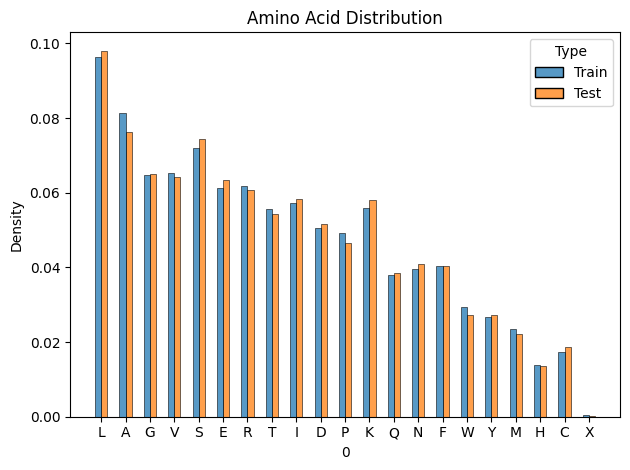

In [14]:
sns.histplot(
  pd.concat([
    pd.DataFrame(train_toks.numpy()).assign(Type="Train"),
    pd.DataFrame(test_toks.numpy()).assign(Type="Test")]),
  x=0, hue="Type", multiple="dodge", shrink=.5, discrete=True, stat="density", common_norm=False
)
plt.xticks(range(4,25), [token for token in "LAGVSERTIDPKQNFWYMHCX"])
plt.title("Amino Acid Distribution")
plt.tight_layout()
plt.show()


Amino acids are not equally represented in the train and test datasets.

### Decoder Training Loss and Accuracy.

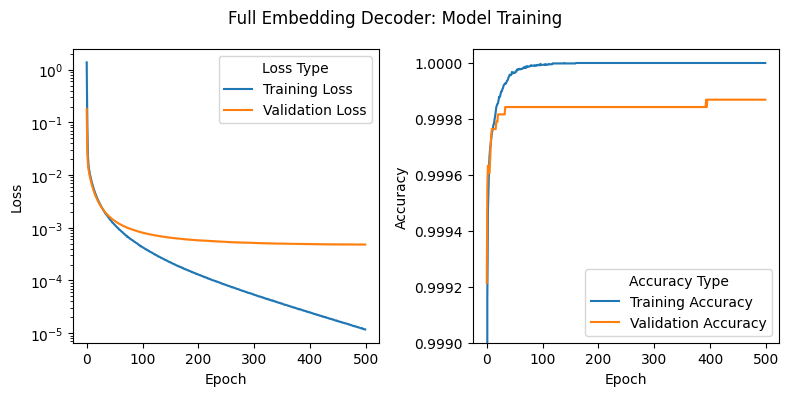

In [15]:
losses_long_df = pd.merge(
    losses_df.melt(id_vars="Epoch",
                   value_vars=["Training Loss", "Validation Loss"],
                   var_name="Loss Type", value_name="Loss")
    , losses_df.melt(id_vars="Epoch",
                   value_vars=["Training Accuracy", "Validation Accuracy"],
                   var_name="Accuracy Type", value_name="Accuracy")
    , on=["Epoch", "Epoch"]
    )

fig, ax = plt.subplots(1, 2, figsize=(8,4))
sns.lineplot(losses_long_df, x="Epoch", y="Loss", hue="Loss Type", ax=ax[0])
sns.lineplot(losses_long_df, x="Epoch", y="Accuracy", hue="Accuracy Type", ax=ax[1])
ax[0].set_yscale("log")
ax[1].set_ylim(0.999, 1.00005)
plt.suptitle("Full Embedding Decoder: Model Training")
plt.tight_layout()

The figure on the left shows the training and validation loss over 500 epochs. As the model starts learning, both the training and validation loss decrease similarly. Between the 50th and 100th epoch, the validation loss diverges from the training loss; approaching the 500th epoch, the training loss continues to decrease, approaching $10^{-5}$ while the validation loss plateaus to $10^{-4}$. This gap might indicate overfitting in conjunction with class imbalance as residues are not equally distributed in nature and in our datasets.

The figure on the right shows the training and validation accuracy over the 500 epochs. The initial epochs show a sharp increase in accuracy on both the training and validation sets. Starting at the 100th epoch, the validation accuracy converges till the end of training to 0.9999, while the training accuracy converges to 1.000; perhaps accuracy is not appropriate for this imbalanced dataset.

Past the 75th epoch, the model begins to overfit to the training data, evident with the validation loss diverging from the training loss. Therefore, around the 75th epoch, the model strikes a balance of not overfitting to the training data and generalizing to the validation set with comparable accuracy.

In [16]:
with torch.no_grad():
  test_embeddings = test_embeddings.to("cuda")
  outputs_test = esm_decoder(test_embeddings).cpu()
  loss_test = loss_fn(outputs_test, test_toks)
  optimizer.zero_grad()


{ "Test Loss": loss_test.item(),
  "Test Accuracy": ((outputs_test.argmax(dim=1) == test_toks).sum() / test_toks.shape[0]).item(),
  "Test F1": multiclass_f1_score(outputs_test, test_toks, 33),
  "Test Recall": multiclass_recall(outputs_test, test_toks, 33),
  "Test Precision": multiclass_precision(outputs_test, test_toks, 33),
  "Test Specificity": multiclass_specificity(outputs_test, test_toks, 33),
  "Test AUROC - weighted": multiclass_auroc(outputs_test, test_toks, 33, average="weighted"),
  "Test AUROC - macro": multiclass_auroc(outputs_test, test_toks, 33, average="macro")
}

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


{'Test Loss': 0.00023358869657386094,
 'Test Accuracy': 0.999947190284729,
 'Test F1': tensor(1.0000),
 'Test Recall': tensor(0.9999),
 'Test Precision': tensor(1.0000),
 'Test Specificity': tensor(1.0000),
 'Test AUROC - weighted': tensor(1.),
 'Test AUROC - macro': tensor(0.6364)}

In [17]:
"Test AUROC - macro modified", multiclass_auroc(outputs_test[:, 4:25], test_toks-4, 21, average="macro")

('Test AUROC - macro modified', tensor(1.))

In [19]:
torch.cuda.empty_cache()

When assessing the test dataset, additional metrics are required for an imbalanced datasets. Looking at the AUROC scores, the difference between the weighted 1.0 and macro 0.6364 indicates the model performs slightly better than random when weighting all residues equally. However, this might be an artifact of ESM special tokens not found in nature; this can be seen with the AUROC modified macro of 1.0 that only contains naturally occurring amino acids.

We are successful in training a near-perfect decoder that maps between the full ESM embedding and residue. Which is expected of this task because the full embeddings contain residue-level data, which becomes a lookup task.

# 04: Train mean-pooled embedding decoder.

In this regime, we are tasked to predict the entire amino acid sequence from a given mean-pooled embedding vector. One approach is to iteratively generate the amino acid sequence given the pooled embedding vector and the previously generated token. The approach resembles the RNN (recurrent neural network) structure, sequentially generating tokens given the hidden state of the previous step. LSTM is a RNN designed to avoid some of RNN's common pitfalls: vanishing gradients and poor long range dependencies. Moreover, LSTMs serve as a basis for more complex model architectures.

- Define functions to help with the training process.

In [20]:
def batch_encode(sequences, alphabet, max_length=1022):
  "Return an N x M tensor of encoded amino acid sequence."
  encoded_sequences = []
  _max_length = max([len(sequence) for sequence in sequences])
  max_length = min(_max_length, max_length)

  for i in range(len(sequences)):
    _encoded_seq = torch.tensor(alphabet.encode(sequences[i][:max_length]))
    _seq_length = _encoded_seq.shape[0]
    _encoded_seq = torch.nn.functional.pad(_encoded_seq, (0, max_length-_seq_length), value=0)
    encoded_sequences.append(_encoded_seq)
  return torch.stack(encoded_sequences)

def batched_training_indices(n_sequence, max_length, batch_size:int=3, n_epoch:int=2):
  "Returns a list of tuples "
  sequence_lengths = list(range(max_length))
  sequence_indices = list(range(n_sequence))

  batched_indices = []
  for epoch in range(n_epoch):
    sequence_lengths = np.random.permutation(sequence_lengths)
    for length in sequence_lengths:
      sequence_indices = np.random.permutation(sequence_indices)
      n_splits = math.ceil(len(sequence_indices) / batch_size)
      for _batched_indices in np.array_split(sequence_indices, n_splits):
        batched_indices.append((epoch, length.item(), _batched_indices))
  return batched_indices

In [21]:
print(batched_training_indices(1, 3))
print(batch_encode([out[i]["Sequence"] for i in range(2)], alphabet=alphabet))

[(0, 2, array([0])), (0, 1, array([0])), (0, 0, array([0])), (1, 0, array([0])), (1, 2, array([0])), (1, 1, array([0]))]
tensor([[20,  6, 11, 15, 23, 19,  4, 23, 13,  6,  8],
        [ 4,  4, 24,  8, 13, 14,  4,  8, 16, 19, 20]])


In [22]:
class ESM_Conditional_LSTM_Decoder(nn.Module):
  def __init__(self, alphabet_size:int = 31, latent_dim:int = 320,
               model_hidden_dim:int = 180, layers:int = 1, dropout: float = 0.1
               ):
    super().__init__()
    self.layers = layers
    self.model_hidden_dim = model_hidden_dim

    self.h0_linear = nn.Linear(latent_dim, model_hidden_dim * layers)
    self.c0_linear = nn.Linear(latent_dim, model_hidden_dim * layers)

    self.lstm = nn.LSTM(latent_dim, model_hidden_dim, layers)
    self.linear = nn.Linear(model_hidden_dim, alphabet_size)
    self.dropout = nn.Dropout(dropout)

  def init_state(self, latent):
    _, batch_size, _ = latent.shape

    h0 = self.h0_linear(latent).view(self.lstm.num_layers, batch_size, self.lstm.hidden_size).tanh() # torch.zeros((self.layers, batch_size, self.model_hidden_dim))
    c0 = self.c0_linear(latent).view(self.lstm.num_layers, batch_size, self.lstm.hidden_size).tanh() # torch.zeros((self.layers, batch_size, self.model_hidden_dim))
    return h0, c0

  def forward(self, latent, h, c, dropout=True):
    out, (h, c) = self.lstm(latent, (h, c))
    if dropout:
      out = self.dropout(out)
    logits = self.linear(out)
    return logits, h, c

  def sample(self, latent, max_length:int = 50, temp:int|None=None):
    out_seqs, out_logits = [], []
    with torch.no_grad():
      h, c = self.init_state(latent)
      for _ in range(max_length):
        logits, h, c = self.forward(latent, h, c, dropout=False)

        if temp is not None:
          logits = logits / max(temp, 1e-6)
          probs = nn.functional.softmax(logits, dim=-1).squeeze(0)
          out_seqs.append(torch.multinomial(probs, num_samples=1))
        else:
          out_seqs.append(logits.argmax(dim=-1))
        out_logits.append(logits)

    out_seqs = torch.stack(out_seqs, dim=-1).squeeze(0)
    out_logits = torch.stack(out_logits, dim=-1).squeeze(0)
    return out_seqs, out_logits

In [23]:
def batched_training_indices(n_sequence, max_length, batch_size:int=3, n_epoch:int=2):
  "Returns"
  sequence_lengths = list(range(max_length))
  sequence_indices = list(range(n_sequence))

  batched_indices = []
  for epoch in range(1, n_epoch+1):
    sequence_lengths = np.random.permutation(sequence_lengths)
    for length in sequence_lengths:
      sequence_indices = np.random.permutation(sequence_indices)
      n_splits = math.ceil(len(sequence_indices) / batch_size)
      for _batched_indices in np.array_split(sequence_indices, n_splits):
        batched_indices.append((epoch, length.item(), _batched_indices))
  return batched_indices


batched_training_indices(5, 3)

[(1, 0, array([0, 4, 2])),
 (1, 0, array([3, 1])),
 (1, 1, array([3, 2, 0])),
 (1, 1, array([4, 1])),
 (1, 2, array([3, 0, 4])),
 (1, 2, array([1, 2])),
 (2, 1, array([3, 4, 1])),
 (2, 1, array([0, 2])),
 (2, 2, array([1, 2, 4])),
 (2, 2, array([3, 0])),
 (2, 0, array([1, 0, 4])),
 (2, 0, array([3, 2]))]

In [32]:
sequences = [out[i]["Sequence"] for i in range(10_000)]
embeddings = torch.tensor([out[i]["mean_embedding"] for i in range(10_000)])
toks = batch_encode(sequences, alphabet=alphabet)

val_latent = embeddings[9_000:10_000].unsqueeze(0)
val_target_toks = toks[9_000:10_000,:20]

The training dataset will consist of 9,000 amino acid sequences with max length of 20 residues. The batch_size is 900 sequences with a total of 1,000 epochs.

In [34]:
esm_decoder = ESM_Conditional_LSTM_Decoder(layers=3, dropout=0.15)
esm_decoder.to("cuda")
esm_decoder.train()
optimizer = torch.optim.AdamW(esm_decoder.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

max_length=20
log = {}

for epoch, sequence_length, indices in tqdm(
    batched_training_indices(9_000, max_length, batch_size=900, n_epoch=1_000),
    smoothing=0.1
    ):
  # Run Validation
  if (epoch == 1 or epoch % 25 == 0) and epoch not in log:
    with torch.no_grad():
      val_latent = val_latent.to("cuda")
      val_pred_seq, val_logits = esm_decoder.sample(val_latent, max_length=max_length, temp=None)
      val_pred_seq, val_logits = val_pred_seq.cpu(), val_logits.cpu()
      val_log = {
        "Val Loss": criterion(val_logits, val_target_toks).item(),
        "Val Accuracy": multiclass_accuracy(val_logits, val_target_toks, 31).item(),
        "Val F1": multiclass_f1_score(val_logits, val_target_toks, 31).item(),
        "Val Recall": multiclass_recall(val_logits, val_target_toks, 31).item(),
        "Val Precision": multiclass_precision(val_logits, val_target_toks, 31).item(),
        "Val Specificity": multiclass_specificity(val_logits, val_target_toks, 31).item(),
        "Val AUROC - weighted": multiclass_auroc(val_logits, val_target_toks, 31, average="weighted").item(),
        "Val AUROC - macro": multiclass_auroc(val_logits, val_target_toks, 31, average="macro").item()
      }
      log[epoch] = val_log | {"Train Loss": [], "Train Accuracy": []}
      if epoch % 50 == 0:
        print(epoch, log[epoch])
  elif epoch not in log:
    log[epoch] = {"Train Loss": [], "Train Accuracy": []}

  _latent = embeddings[indices].unsqueeze(0)
  _latent = _latent.to("cuda")
  _previous_toks = toks[indices,:sequence_length]
  _target_toks = toks[indices,sequence_length]

  h, c = esm_decoder.init_state(_latent)
  h, c = h.to("cuda"), c.to("cuda")
  for _ in range(sequence_length+1):
    logits, h, c = esm_decoder(_latent, h, c)
    logits = logits.cpu()
  loss = criterion(
      logits.squeeze(0),
      _target_toks
  )
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  log[epoch]["Train Loss"].append(loss.item())
  log[epoch]["Train Accuracy"].append(multiclass_accuracy(logits.squeeze(0), _target_toks, 31).item())

  0%|          | 0/200000 [00:00<?, ?it/s]

50 {'Val Loss': 2.696784734725952, 'Val Accuracy': 0.10410518199205399, 'Val F1': 0.08870457112789154, 'Val Recall': 0.10410518199205399, 'Val Precision': 0.10756249725818634, 'Val Specificity': 0.9564850330352783, 'Val AUROC - weighted': 0.6363535523414612, 'Val AUROC - macro': 0.4313276410102844, 'Train Loss': [], 'Train Accuracy': []}
100 {'Val Loss': 2.7902770042419434, 'Val Accuracy': 0.10690318048000336, 'Val F1': 0.10125011205673218, 'Val Recall': 0.10690318048000336, 'Val Precision': 0.11579655855894089, 'Val Specificity': 0.9565784931182861, 'Val AUROC - weighted': 0.6253973245620728, 'Val AUROC - macro': 0.4275493025779724, 'Train Loss': [], 'Train Accuracy': []}
150 {'Val Loss': 2.8769338130950928, 'Val Accuracy': 0.10698723047971725, 'Val F1': 0.10277287662029266, 'Val Recall': 0.10698723047971725, 'Val Precision': 0.12006352841854095, 'Val Specificity': 0.9564789533615112, 'Val AUROC - weighted': 0.6172976493835449, 'Val AUROC - macro': 0.42430657148361206, 'Train Loss': [

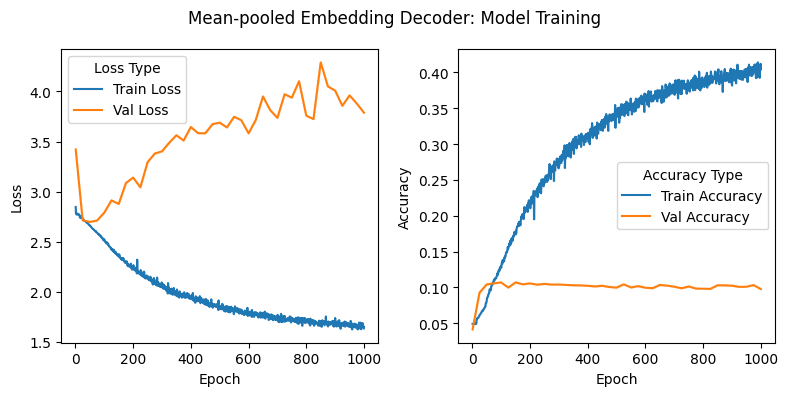

In [47]:
mean_embedding_log_df = pd.DataFrame(log).T
mean_embedding_log_df["Train Loss"] = mean_embedding_log_df["Train Loss"].apply(np.mean)
mean_embedding_log_df["Train Accuracy"] = mean_embedding_log_df["Train Accuracy"].apply(np.mean)
mean_embedding_log_df.index.name = "Epoch"
mean_embedding_log_df.reset_index(inplace=True)

mean_losses_long_df = pd.merge(
    mean_embedding_log_df.melt(id_vars="Epoch",
                   value_vars=["Train Loss", "Val Loss"],
                   var_name="Loss Type", value_name="Loss")
    , mean_embedding_log_df.melt(id_vars="Epoch",
                   value_vars=["Train Accuracy", "Val Accuracy"],
                   var_name="Accuracy Type", value_name="Accuracy")
    , on=["Epoch", "Epoch"]
    )
mean_losses_long_df
fig, ax = plt.subplots(1, 2, figsize=(8,4))
sns.lineplot(mean_losses_long_df, x="Epoch", y="Loss", hue="Loss Type", ax=ax[0])
sns.lineplot(mean_losses_long_df, x="Epoch", y="Accuracy", hue="Accuracy Type", ax=ax[1])
plt.suptitle("Mean-pooled Embedding Decoder: Model Training")
plt.tight_layout()

The left figure shows the training and validation loss over 1000 epochs, the validation loss starts diverging from the training loss at the first epoch. While training loss steadily decreases approaching ~1.5 loss, validation loss increases with high variance to ~3.7 loss. Clearly the model is not generalizing to the validation dataset within the 1000 epochs.

The right figure shows the training and validation accuracy over 1000 epochs. The training accuracy increases steadily approaches 0.4 with potential to surpass 0.4, while the validation accuracy increases initially but plateaus to 0.1. An accuracy of 0.1 is only slighly better than random, 1/20, 0.05, indicating the model is likely learning the frequency of residues rather any meaningful sequence patterns.

The conditional generation on the mean-pooled embedding model is memorizing the training data and predicting the frequency of tokens.

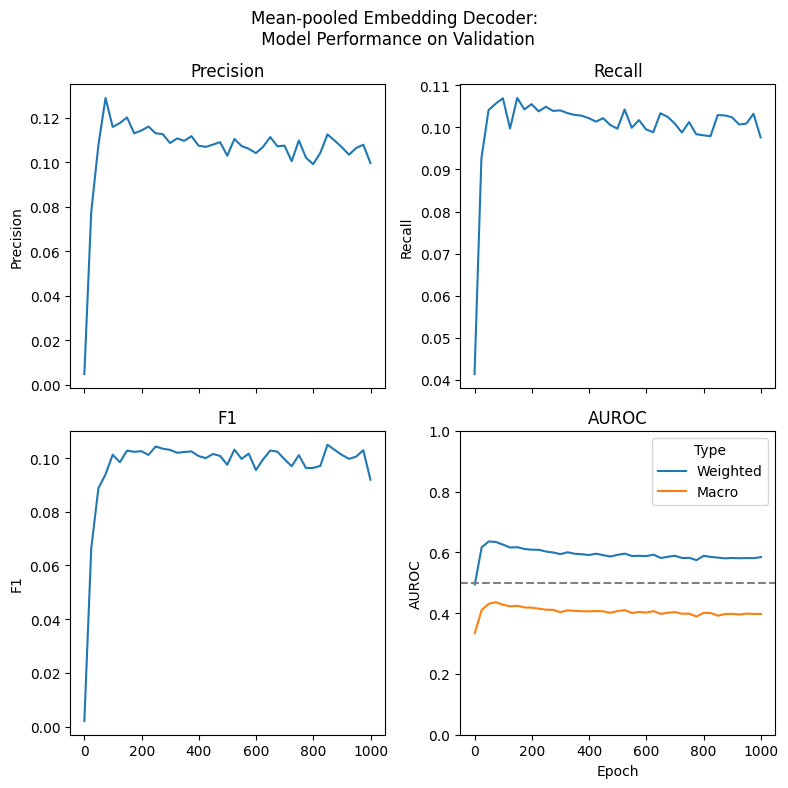

In [36]:
mean_embedding_log_auroc_long_df = pd.melt(
    mean_embedding_log_df.rename(
        columns={"Val AUROC - weighted": "Weighted", "Val AUROC - macro": "Macro"}
    ), id_vars="Epoch",
    value_vars=["Weighted", "Macro"],
    var_name="Type", value_name="AUROC"
)

fig, ax = plt.subplots(2,2, figsize=(8,8), sharex=True)
plt.suptitle("Mean-pooled Embedding Decoder:\n Model Performance on Validation")
sns.lineplot(mean_embedding_log_df["Val Precision"], ax=ax[0,0])
sns.lineplot(mean_embedding_log_df["Val Recall"], ax=ax[0,1])
sns.lineplot(mean_embedding_log_df["Val F1"], ax=ax[1,0])
sns.lineplot(mean_embedding_log_auroc_long_df, x="Epoch", y="AUROC",
             hue="Type", ax=ax[1,1])

ax[0,0].set_title("Precision")
ax[0,1].set_title("Recall")
ax[1,0].set_title("F1")
ax[1,1].set_title("AUROC")

ax[0,0].set_ylabel("Precision")
ax[0,1].set_ylabel("Recall")
ax[1,0].set_ylabel("F1")
ax[1,1].set_ylabel("AUROC")

ax[1,1].set_ylim(0, 1)

ax[1,1].axhline(0.5, linestyle="--", color="grey")
plt.tight_layout()

This figure shows Precision, Recall, F1 and AUROC of the validation set over the 1000 epochs. The evaluation metrics converge by the 100th epoch, to 0.10 for Precision, Recall and F1, indicating the model is unable to recover the amino acid sequence given the mean-pooled embedding. For AUROC, the weighted AUROC converges to 0.6 slighly better than random, the dashed line at 0.5, while the macro AUROC converges to 0.4. The gap between the AUROC metrics is a function of imbalanced amino acid frequencies in the training data where the weighted AUROC is artifically inflated.

The model is collapsed, converges to predicting tokens with high frequencies and unable to generalize across tokens. Given the current architecture and parameters, additional epochs will not improve model generalization.



In [37]:
example_latent = embeddings[0].unsqueeze(0).unsqueeze(0)
example_toks = toks[0]

with torch.no_grad():
  example_latent = example_latent.to("cuda")
  example_pred_seq, example_logits = esm_decoder.sample(example_latent, max_length=max_length, temp=None)
  example_pred_seq, example_logits = example_pred_seq.cpu(), example_logits.cpu()
example_pred_seq, example_toks[:20]

(tensor([[20,  5, 20, 15,  6, 13,  4, 23, 13,  6,  8, 13,  0,  0,  0,  0,  0,  0,
           0,  0]]),
 tensor([20,  6, 11, 15, 23, 19,  4, 23, 13,  6,  8,  0,  0,  0,  0,  0,  0,  0,
          0,  0]))

In [46]:
test_sequences = [out[i]["Sequence"] for i in range(10_000, 10_500)]
test_embeddings = torch.tensor([out[i]["mean_embedding"] for i in range(10_000, 10_500)])
test_embeddings = test_embeddings.unsqueeze(0)
test_toks = batch_encode(test_sequences, alphabet=alphabet)[:,:20]

with torch.no_grad():
  test_embeddings = test_embeddings.to("cuda")
  test_pred_seq, test_logits = esm_decoder.sample(test_embeddings, max_length=max_length, temp=None)
  test_pred_seq, test_logits = test_pred_seq.cpu(), test_logits.cpu()
  test_result = {
    "Test Loss": criterion(test_logits, test_toks).item(),
    "Test Accuracy": multiclass_accuracy(test_logits, test_toks, 31).item(),
    "Test F1": multiclass_f1_score(test_logits, test_toks, 31).item(),
    "Test Recall": multiclass_recall(test_logits, test_toks, 31).item(),
    "Test Precision": multiclass_precision(test_logits, test_toks, 31).item(),
    "Test AUROC - weighted": multiclass_auroc(test_logits, test_toks, 31, average="weighted").item(),
    "Test AUROC - macro": multiclass_auroc(test_logits, test_toks, 31, average="macro").item()
  }
test_result

{'Test Loss': 4.300600528717041,
 'Test Accuracy': 0.1027471050620079,
 'Test F1': 0.10272126644849777,
 'Test Recall': 0.1027471050620079,
 'Test Precision': 0.11092643439769745,
 'Test AUROC - weighted': 0.5773748755455017,
 'Test AUROC - macro': 0.37070292234420776}

The test set confirms the observations from the validation plots, the model has not learned a meaningful mapping, achieving an accuracy of 0.103 and an AUROC-macro of 0.371 on the test set, indicating model collapse. The gap between Accuracy and Precision of 0.111 might indicate some correct tokens or an artifact of most proteins start with methionine, but with AUROC-macro 0.37 < 0.5, model collapse is primary issue.

# Takeaways


| Metric | Full-Length Embedding Decoder | Mean-Pooled Embedding Decoder |
|---|---|---|
| Test Accuracy | 0.9998 | 0.103 |
| Test Precision | 0.9998 | 0.111 |
| Test AUROC - Weighted | 1.0 | 0.577 |
| Test AUROC - Macro | 1.0 | 0.371 |


This project attempts to train two decoders for the ESM-2 model, learning a mapping between the ESM-2 embeddings and residues. We were successful in learning a near-ideal mapping between full-length ESM-2 embeddings and residues, achieving an accuracy of 0.9998 on the test set with an AUROC of 1.0, indicating the model is unbiased across the natural residues. This is an easy look-up task with full-length embeddings containing residue-level information. At inference time, each residue of a sequence is predicted independently, such that a sequence of length l requires l passes.

The second decoder's task is to learn a mapping between the mean-pooled embedding and residue; this task is difficult as we average over the length of the sequence, losing residue-level information. During model training, the validation loss was highly variable. The test set confirms the model collapse, the test accuracy of 0.103 and AUROC-macro of 0.371 indicate the model performs worse than random when weighting all residues equally.

### Further Investigation

Although we were able to learn a near-ideal mapping of the full-embeddings and residues, it would be ideal to address the special tokens by excluding them in the evaluation metrics and include a weighted loss to account for natural residue frequency bias.

The largest room for investigation is with the learning of a mapping between the mean-pooled embeddings and residues. Expanding on LSTMs, we can incorporate teacher forcing during training to reduce initial errors propagating due to autoregressively predicting residues, or different sampling strategies to alleviate model collapse. Alternatively, we can try other autoregressive architectures, such as transformers and VAE, and assess if training difficulties persist. Simultaneously, we can curate our training and validation sets to a simpler task, such as a smaller alphabet size or a handful of sequences, so that we can examine training convergence.

### Connection to Previous Notebooks

The previous notebooks focused on exploring species biases in ESM-2, relying on the log-likelihood computations; on the contrary, this notebook attempts to train new decoders using the ESM-2 embeddings. In application, we can use this framework of training these decoders downstream of a fine-tuned ESM-2 model because the fine-tuning procedure would create new embeddings, refined towards the *A. baylyi* proteome. For example, we can identify promising candidates in the *A. baylyi* fine-tuned embedding space using optimization strategies, then map back to residue space such that our candidates have a similar sequence composition to the *A. baylyi* proteome.